# Train a Small Robust Neural Network
This notebook covers training a small, *robust* neural network for a 2D classification task using interval bound propagation (IBP).
The network is robust if it predicts the same class for all points inside the black boxes.

Let's first look at the data we will fit. This is similar to the data in the demo notebook.

In [1]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
from matplotlib import patches

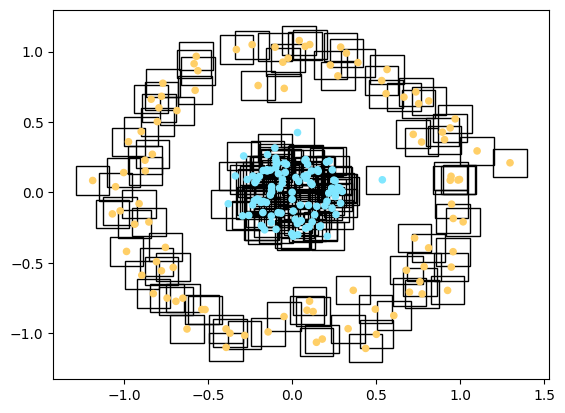

In [2]:
data, targets = make_circles(noise=0.1, random_state=2212, factor=0.2, n_samples=200)
eps = 0.1

def plot_data(ax=None):
    if ax is None:
        _, ax = plt.subplots()
    for point in data:
        rect = patches.Rectangle(
            (point[0] - eps, point[1] - eps),2 * eps, 2 * eps,
            facecolor="none", edgecolor="black",
        )
        ax.add_patch(rect)
    ax.scatter(data[:, 0], data[:, 1], c=targets, s=20, cmap="managua")

plot_data()
plt.show()

## Neural Network
We use the same architecture as in the demo notebook. 

In [3]:
from minijax.core import relu
from minijax.eval import Array, zeros
from minijax.random import rand_uniform
from minijax.vmap import vmap


In [4]:
def network_(x, params):
    layer1_params, layer2_params = params
    # @ is matmul
    z = layer1_params["weight"] @ x + layer1_params["bias"]
    z = relu(z)
    return layer2_params["weight"] @ z + layer2_params["bias"]

network = vmap(network_, (0, None))

In [5]:
input_size = 2
hidden_neurons = 30
out_size = 1

params = [
    {"weight": rand_uniform((hidden_neurons, input_size), rng_key=0), "bias": zeros(hidden_neurons)},
    {"weight": rand_uniform((out_size, hidden_neurons), rng_key=1), "bias": zeros(out_size)},
]

In [6]:
x = Array(data[0:5])
network(x, params)

Array([[0.        ]
       [0.71245349]
       [2.01274369]
       [2.02643215]
       [0.21037775]])

## ibp
Let's perform ibp on the network to observe the initial bounds we obtain for the first few datapoints. 


In [7]:
from mininnverifier.ibp import ibp, Box

In [8]:
def print_bounds(params):
    x = Array(data[0:5])
    x_lb = x - Array(eps)
    x_ub = x + Array(eps)
    in_bounds = Box(x_lb, x_ub)

    out = network(x, params)
    out_bounds = ibp(network)(in_bounds, params)
    
    for i in range(x.shape[0]):
        lb = out_bounds.lb.array[i].item()
        ub = out_bounds.ub.array[i].item()
        print(f"{i}:   {lb:8.4f} <= {out.array[i].item():8.4f} <= {ub:8.4f}          margin: {ub - lb:8.4f}")

print_bounds(params)

0:     0.0000 <=   0.0000 <=   0.0478          margin:   0.0478
1:     0.0960 <=   0.7125 <=   1.9808          margin:   1.8848
2:     0.7051 <=   2.0127 <=   3.4675          margin:   2.7625
3:     0.5787 <=   2.0264 <=   3.4812          margin:   2.9025
4:     0.0514 <=   0.2104 <=   0.3998          margin:   0.3484


## Training


In [9]:
import numpy as np

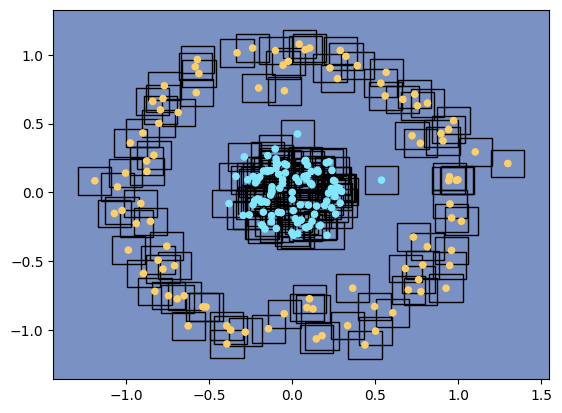

In [10]:
def plot_decision_boundary(params):
    x1 = np.linspace(data[:,0].min() - 0.25, data[:,0].max() + 0.25, 100)
    x2 = np.linspace(data[:,1].min() - 0.25, data[:,1].max() + 0.25, 100)
    x1, x2 = np.meshgrid(x1, x2)
    x = np.stack([x1.ravel(), x2.ravel()], axis=1)
    score = network(Array(x), params)
    score = score.array.reshape(100, 100)
    _, ax = plt.subplots()
    ax.contourf(x1, x2, score >= 0, cmap="managua", alpha=0.8)
    plot_data(ax)

plot_decision_boundary(params)

### Loss

Let's set up a loss function that rewards the network for being robust under the ibp bounds.
We'll train once without the robustness regularizer in the loss and once with it, to see the difference.

In [11]:
from copy import deepcopy

from minijax.core import exp, log, reduce_sum, reshape
from minijax.grad import grad
from minijax.jit import jit
from minijax.nested_containers import map_structure


In [12]:
lr = Array(1.0)
batch_size = 10
epochs = 500


In [13]:
def cross_entropy(y_true, y_pred):
    y_pred = Array(1) / (Array(1) + exp(-y_pred))  # sigmoid(scores)
    y_true = reshape(y_true, (-1, 1))
    error = y_true * log(y_pred) + (Array(1) - y_true) * log(Array(1) - y_pred)
    return -reduce_sum(error) / Array(data.shape[0])  # cross-entropy loss

def ce_loss(params, x, y_true):
    scores = network(x, params)
    return cross_entropy(y_true, scores)

eps_ = Array(eps)

def robust_loss(params, x, y_true):
    x_bounds = Box(x - eps_, x + eps_)
    score_bounds = ibp(network)(x_bounds, params)
    # We want to:
    #  - push up the lower bound for class 1 (=> bigger scores)
    #  - push down the upper bound for class 0 (=> smaller scores)
    # Select the score lower bound for class 1 and the upper bound for class 0
    # and compute the loss from this for the robustness loss
    scores = y_true * score_bounds.lb + (Array(1) - y_true) * score_bounds.ub
    return cross_entropy(y_true, scores)


First the regular training run with the regular cross entropy loss.

In [ ]:
default_params = deepcopy(params)

@jit
def train_step(params, x, y_true):
    g = grad(ce_loss)(params, x, y_true)[0]
    return map_structure(lambda p, g: p - lr * g, params, g)

for epoch in range(epochs):
    for i in range(data.shape[0] // batch_size):
        x, y_true = data[i*batch_size:(i+1)*batch_size], targets[i*batch_size : (i+1)*batch_size]
        x, y_true = Array(x), Array(y_true)
        default_params = train_step(default_params, x, y_true)

    if epoch % 50 == 49:
        print(epoch+1, ":", ce_loss(default_params, Array(data), Array(targets)))

50 : Array(0.4286154349761676)
100 : Array(0.08916472467152037)
150 : Array(0.04136826317005373)
200 : Array(0.026568299617936973)


Now the robustness training with the robustness loss.

In [ ]:
robust_params = deepcopy(params)

@jit
def train_step(params, x, y_true):
    g = grad(robust_loss)(params, x, y_true)[0]
    return map_structure(lambda p, g: p - lr * g, params, g)

for epoch in range(epochs):
    for i in range(data.shape[0] // batch_size):
        x, y_true = data[i*batch_size:(i+1)*batch_size], targets[i*batch_size : (i+1)*batch_size]
        x, y_true = Array(x), Array(y_true)
        robust_params = train_step(robust_params, x, y_true)

    if epoch % 50 == 49:
        print(epoch+1, ":", robust_loss(robust_params, Array(data), Array(targets)))

Let's plot the two networks side by side!

In [ ]:
plot_decision_boundary(default_params)
plt.show()
plot_decision_boundary(robust_params)
plt.show()

Let's also compare the ibp bounds for both parameter sets.

In [ ]:
print("Default")
print("================================")
print_bounds(default_params)

print("Robust")
print("================================")
print_bounds(robust_params)

As we can see in the plots, the robustness training makes the network 